# Giới thiệu Matplotlib / Introduction to Matplotlib

**Thời gian ước tính / Estimated time:** 30–40 phút

Notebook này là hướng dẫn Matplotlib từ đầu: thư viện là gì, cách import, hai kiểu API, rồi lần lượt vẽ **line**, **scatter**, **bar**, **histogram** và **subplots**. Mỗi phần có giải thích ngắn và ví dụ chạy được ngay.

This notebook is a standalone Matplotlib tutorial: what the library is, how to import it, the two APIs, then line, scatter, bar, histogram, and subplots — each with a short explanation and a working example.

## Mục tiêu / Objectives

Sau khi hoàn thành, bạn sẽ:

* Hiểu Matplotlib là gì và khi nào nên dùng
* Phân biệt **Pyplot API** (`plt.plot`) và **Object-Oriented API** (`fig, ax`)
* Vẽ **line**, **scatter**, **bar**, **histogram**
* Ghép nhiều biểu đồ bằng **subplots**

After this tutorial you will be able to import Matplotlib, choose an API style, and create the most common plot types.


## Mục lục / Table of Contents

1. [Matplotlib là gì?](#matplotlib-la-gi)
2. [Import thư viện và style](#import)
3. [Hai cách vẽ: Pyplot vs OO](#hai-cach-ve)
4. [Line plot](#line)
5. [Scatter plot](#scatter)
6. [Bar chart](#bar)
7. [Histogram](#hist)
8. [Subplots](#subplots)
9. [Tóm tắt](#tom-tat)


## 1. Matplotlib là gì? <a id="matplotlib-la-gi"></a>

**Matplotlib** là thư viện vẽ đồ thị 2D (và một phần 3D) cho Python. Trong khoa học dữ liệu, người ta thường dùng nó để:

* Quan sát phân phối, xu hướng, mối quan hệ giữa các biến
* So sánh nhóm (doanh số, tần suất, …)
* Xuất hình cho báo cáo / bài tập

**Matplotlib** is Python’s standard 2D plotting library. In data science it is used to inspect distributions, trends, and relationships, and to export figures for reports.

Module hay dùng nhất là `matplotlib.pyplot`, thường được import với bí danh `plt`.

The most common entry point is `matplotlib.pyplot`, imported as `plt`.


## 2. Import thư viện và style <a id="import"></a>

Chạy cell dưới để nạp NumPy (tạo dữ liệu) và Matplotlib (vẽ). Pandas được import sẵn nếu bạn muốn vẽ từ DataFrame sau này.

Run the cell below to load NumPy and Matplotlib. Pandas is included so you can plot from a DataFrame later if needed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Matplotlib có nhiều **style** có sẵn (giao diện lưới, màu sắc, font). `plt.style.available` liệt kê tên style. Ở đây dùng `seaborn-v0_8-darkgrid` — có lưới, dễ đọc trên notebook.

Matplotlib ships many visual **styles**. `plt.style.available` lists them. This tutorial uses `seaborn-v0_8-darkgrid` because the grid makes plots easier to read.


In [3]:
print("Một vài style / A few styles:")
print(plt.style.available[:10])

plt.style.use("seaborn-v0_8-darkgrid")


Một vài style / A few styles:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot']


`plt.style.use(...)` **không vẽ gì**. Nó chỉ đổi giao diện cho các figure tạo **sau** lệnh này.

`plt.plot()` không có dữ liệu ra khung trống, nên `darkgrid` (nền xám + lưới) rất khó nhận ra. Muốn thấy khác biệt, hãy so sánh hai style trên cùng một đường.


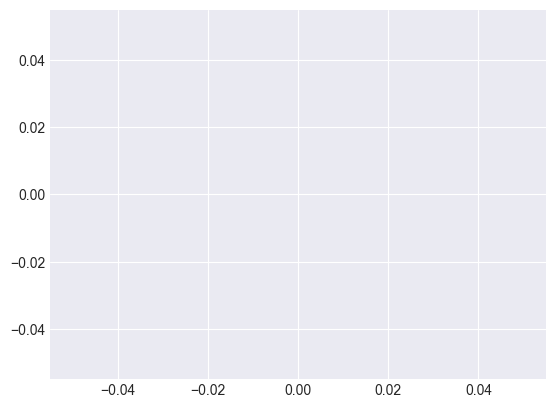

In [4]:
plt.plot();


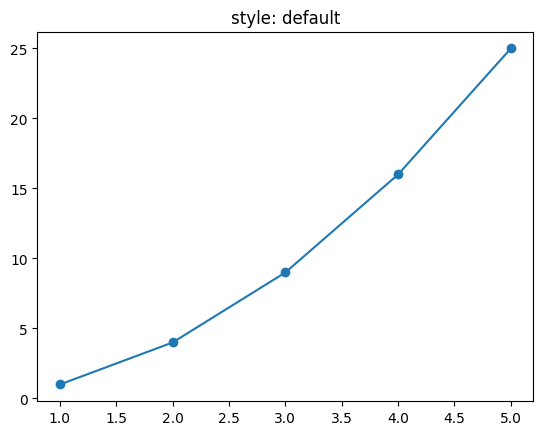

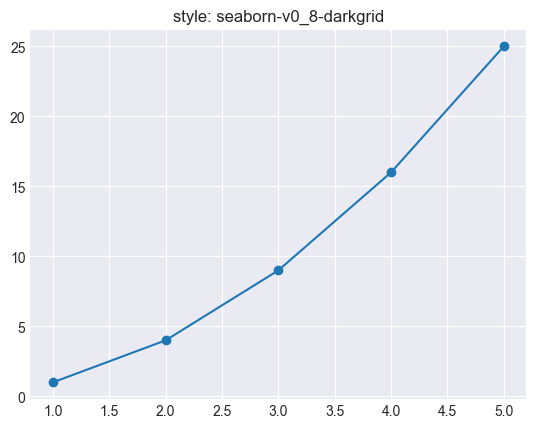

In [5]:
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

# Vẽ hai figure riêng — style chỉ áp dụng cho figure tạo bên trong with
with plt.style.context("default"):
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.title("style: default")
    plt.show()

with plt.style.context("seaborn-v0_8-darkgrid"):
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.title("style: seaborn-v0_8-darkgrid")
    plt.show()


## 3. Hai cách vẽ: Pyplot vs OO <a id="hai-cach-ve"></a>

Matplotlib có **hai API** chính:

| Cách / Style | Viết tắt | Ý tưởng |
|---|---|---|
| **Pyplot (state-based)** | `plt.plot`, `plt.xlabel`, … | Matplotlib nhớ “trục hiện tại”. Nhanh cho 1 hình đơn giản. |
| **Object-Oriented** | `fig, ax = plt.subplots()` rồi `ax.plot(...)` | Bạn giữ object `Figure` và `Axes`. Rõ ràng hơn khi có nhiều subplot. |

Có hai khái niệm cần nhớ:

* **Figure (`fig`)**: cả khung hình (tờ giấy)
* **Axes (`ax`)**: một hệ trục / một biểu đồ bên trong figure

**Pyplot** is convenient for a single quick plot. The **OO API** is preferred when you combine several charts, because each subplot is an explicit `Axes` object.


### 3.1. Pyplot: vẽ nhanh một đường / A simple line


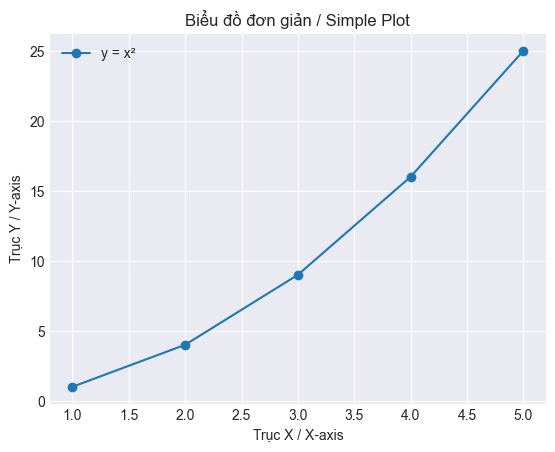

In [6]:
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y, marker="o", label="y = x²")
plt.xlabel("Trục X / X-axis")
plt.ylabel("Trục Y / Y-axis")
plt.title("Biểu đồ đơn giản / Simple Plot")
plt.legend()
plt.show()


### 3.2. Nhiều đường, màu, nét đứt / Multiple lines

`np.linspace(start, stop, n)` tạo `n` điểm cách đều từ `start` đến `stop`. Khác với `np.arange(start, stop, step)` (bước cố định).

`np.linspace` takes a **count** of points; `np.arange` takes a **step size**.


In [7]:
x = np.linspace(0, 10, 1000)  # 1000 điểm từ 0 đến 10 / 1000 points from 0 to 10
x[:5]


array([0.        , 0.01001001, 0.02002002, 0.03003003, 0.04004004])

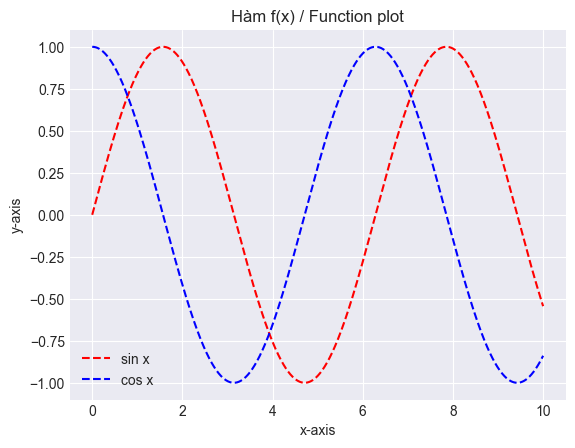

In [8]:
plt.plot(x, np.sin(x), color="red", linestyle="dashed", label="sin x")
plt.plot(x, np.cos(x), color="blue", linestyle="dashed", label="cos x")

plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.title("Hàm f(x) / Function plot")
plt.legend()

# Giới hạn trục (bỏ comment nếu muốn thu phóng)
# Axis limits (uncomment to zoom)
# plt.xlim(0, 4)
# plt.ylim(-0.7, 0.6)

plt.axis("tight")   # ôm sát dữ liệu / fit the data
# plt.axis("equal") # cùng tỉ lệ x và y / equal aspect ratio
plt.show()


### 3.3. Object-Oriented API

Mẫu chuẩn:

```python
fig, ax = plt.subplots(figsize=(width, height))
ax.plot(...)
ax.set(title=..., xlabel=..., ylabel=...)
```

`figsize` tính bằng **inch** (rộng, cao).


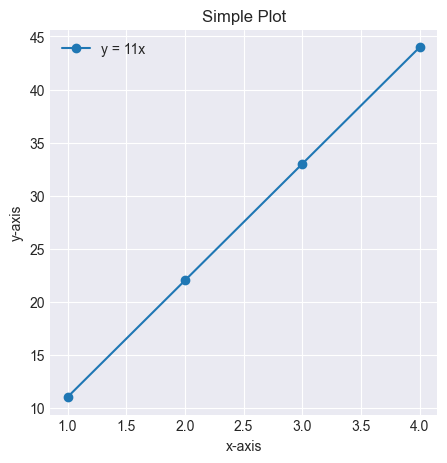

In [9]:
# Chuẩn bị dữ liệu / Prepare data
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]

# Tạo figure + axes / Create figure and axes
fig, ax = plt.subplots(figsize=(5, 5))  # rộng = cao = 5 inch

ax.plot(x, y, marker="o", label="y = 11x")
ax.set(title="Simple Plot", xlabel="x-axis", ylabel="y-axis")
ax.legend()
plt.show()


## 4. Line plot <a id="line"></a>

**Line plot** nối các điểm theo thứ tự — phù hợp chuỗi thời gian hoặc hàm số liên tục.

A **line plot** connects points in order. Use it for trends and continuous functions.


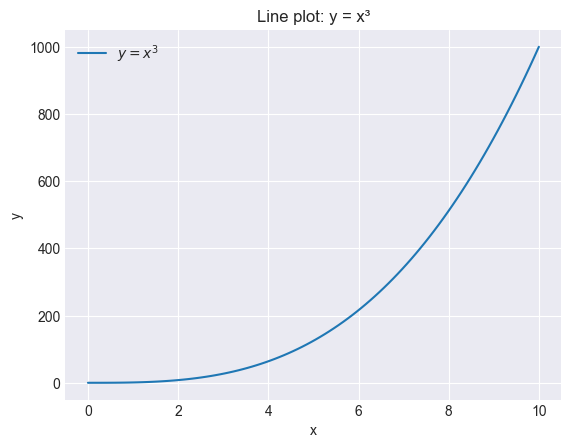

In [10]:
x = np.linspace(0, 10, 100)

fig, ax = plt.subplots()
ax.plot(x, x**3, label=r"$y = x^3$")
ax.set(title="Line plot: y = x³", xlabel="x", ylabel="y")
ax.legend()
plt.show()


## 5. Scatter plot <a id="scatter"></a>

**Scatter** vẽ từng điểm rời, không nối đường. Dùng khi muốn thấy **mối quan hệ** giữa 2 biến, hoặc phân tán.

A **scatter plot** shows individual points. Use it for relationships and spread, not ordered sequences.


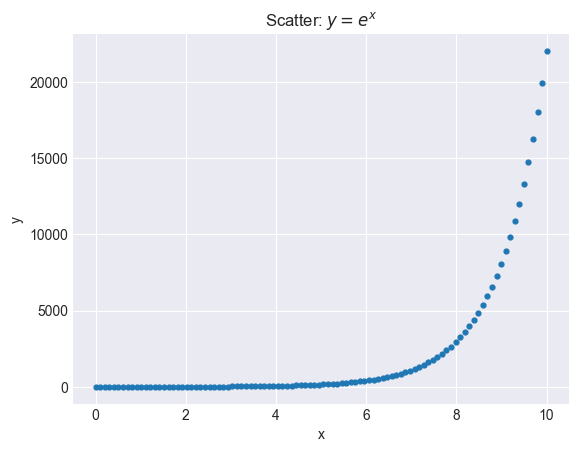

In [11]:
x = np.linspace(0, 10, 100)
plt.scatter(x, np.exp(x), s=12)
plt.title(r"Scatter: $y = e^x$")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


Có thể mã hóa thêm thông tin bằng **kích thước** (`s`) và **màu** (`c`). `alpha` làm điểm trong suốt để chồng lên nhau vẫn nhìn được.

Size (`s`) and color (`c`) can encode extra variables. `alpha` adds transparency so overlapping points remain visible.


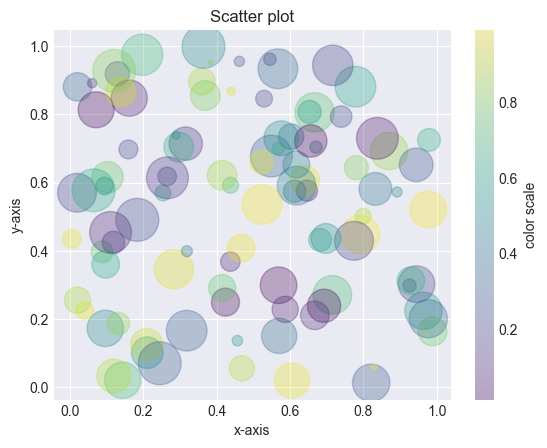

In [12]:
rng = np.random.RandomState(0)
x = rng.rand(100)
y = rng.rand(100)
colors = rng.rand(100)
sizes = 1000 * rng.rand(100)

fig, ax = plt.subplots()
img = ax.scatter(x, y, s=sizes, c=colors, alpha=0.3, marker="o", cmap="viridis")
ax.set_title("Scatter plot")
ax.set_xlabel("x-axis")
ax.set_ylabel("y-axis")
fig.colorbar(img, ax=ax, label="color scale")
plt.show()


## 6. Bar chart <a id="bar"></a>

**Bar** so sánh giá trị theo **danh mục** (tên sản phẩm, nhóm, …). Dữ liệu có thể lấy từ list hoặc dictionary.

A **bar chart** compares values across categories. You can pass lists or a dictionary’s keys/values.


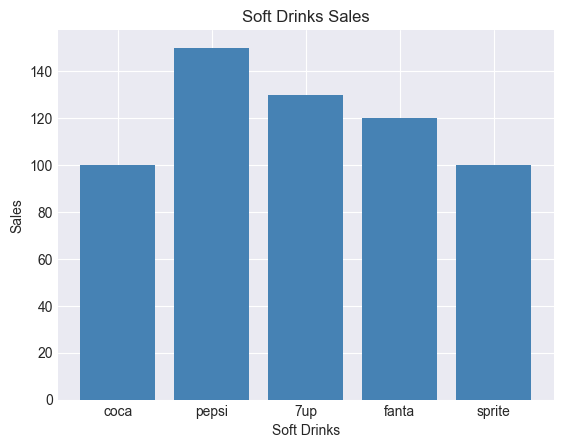

In [13]:
soft_drinks = ["coca", "pepsi", "7up", "fanta", "sprite"]
sales = [100, 150, 130, 120, 100]

dic = {
    "coca": 100,
    "pepsi": 150,
    "7up": 130,
    "fanta": 120,
    "sprite": 100,
}

fig, ax = plt.subplots()
ax.bar(dic.keys(), dic.values(), color="steelblue")
ax.set(xlabel="Soft Drinks", ylabel="Sales", title="Soft Drinks Sales")
plt.show()


`barh` vẽ **cột ngang** — hữu ích khi tên danh mục dài.

`barh` draws **horizontal** bars, which helps when category names are long.


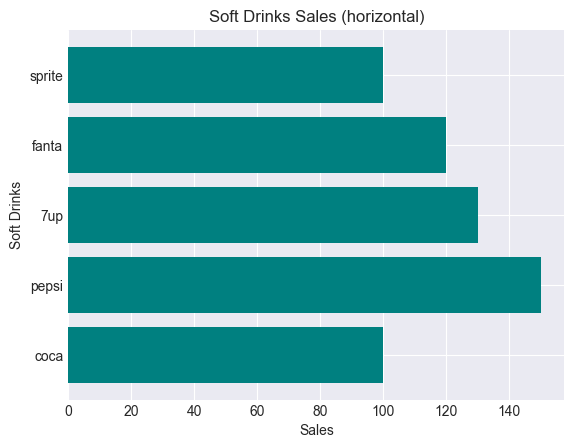

In [14]:
fig, ax = plt.subplots()
ax.barh(list(dic.keys()), list(dic.values()), color="teal")
ax.set(xlabel="Sales", ylabel="Soft Drinks", title="Soft Drinks Sales (horizontal)")
plt.show()


## 7. Histogram <a id="hist"></a>

**Histogram** chia dữ liệu số thành các **khoảng (bins)** rồi đếm tần suất. Không cần thống kê trước — Matplotlib tự chia cột.

A **histogram** bins numeric values and counts how many fall in each bin. You do not pre-aggregate; Matplotlib does the counting.


In [15]:
np.random.seed(42)
# Phân phối chuẩn: trung bình 170 cm, độ lệch chuẩn 10 cm, 250 sinh viên
# Normal distribution: mean 170, std 10, 250 students
student_height = np.random.normal(170, 10, 250)

student_height[:10], len(student_height)


(array([174.96714153, 168.61735699, 176.47688538, 185.23029856,
        167.65846625, 167.65863043, 185.79212816, 177.67434729,
        165.30525614, 175.42560044]),
 250)

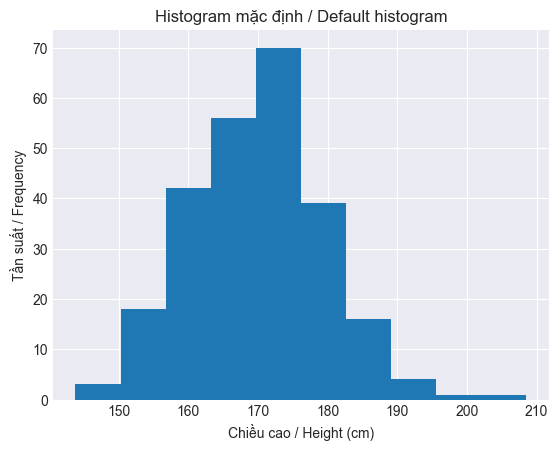

In [16]:
plt.hist(student_height)
plt.title("Histogram mặc định / Default histogram")
plt.xlabel("Chiều cao / Height (cm)")
plt.ylabel("Tần suất / Frequency")
plt.show()


Có thể tùy chỉnh: `edgecolor` viền cột, `bar_label` ghi số trên cột, `grid` lưới.

You can add bar edges, labels on bars, and a grid.


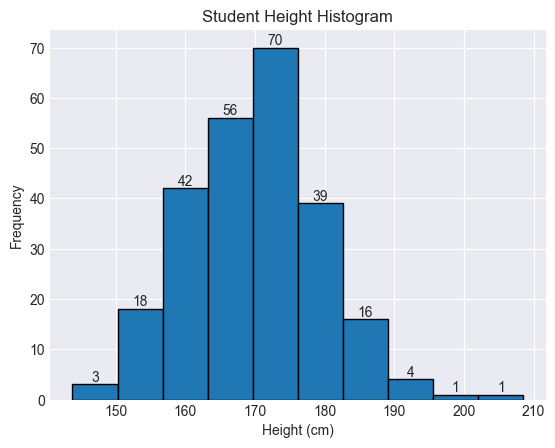

In [17]:
fig, ax = plt.subplots()
n, bins, patches = ax.hist(student_height, edgecolor="black")
# n: số đếm mỗi cột / counts
# bins: mốc chia / bin edges
# patches: các hình chữ nhật cột / bar artists

ax.set(title="Student Height Histogram", xlabel="Height (cm)", ylabel="Frequency")
ax.bar_label(patches)
ax.grid(True)
plt.show()


## 8. Subplots: nhiều biểu đồ trên một figure <a id="subplots"></a>

`plt.subplots(nrows, ncols, figsize=...)` chia figure thành lưới. Có hai cách lấy từng axes.

`plt.subplots` builds a grid of axes. You can unpack them as a 2D layout, or index with `ax[row, col]`.


### Cách 1 — Unpacking: `fig, [(ax1, ax2), (ax3, ax4)]`


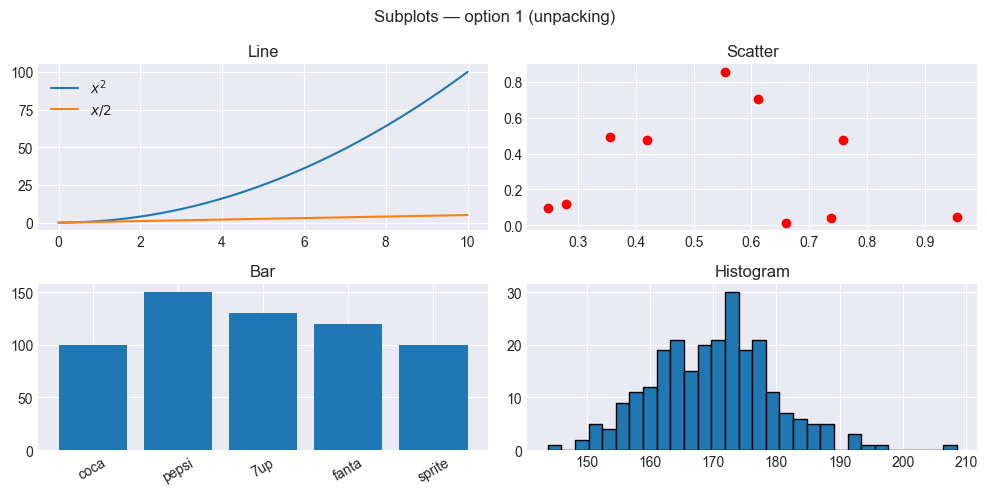

In [18]:
fig, [(ax1, ax2), (ax3, ax4)] = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

x = np.linspace(0, 10, 100)

ax1.plot(x, x**2, label=r"$x^2$")
ax1.plot(x, x / 2, label=r"$x/2$")
ax1.set_title("Line")
ax1.legend()

ax2.scatter(np.random.random(10), np.random.random(10), color="red")
ax2.set_title("Scatter")

ax3.bar(dic.keys(), dic.values())
ax3.set_title("Bar")
ax3.tick_params(axis="x", rotation=30)

ax4.hist(student_height, bins=30, edgecolor="black")
ax4.set_title("Histogram")

fig.suptitle("Subplots — option 1 (unpacking)", fontsize=12)
fig.tight_layout()
plt.show()


### Cách 2 — Index: `ax[hàng, cột]` / `ax[row, col]`


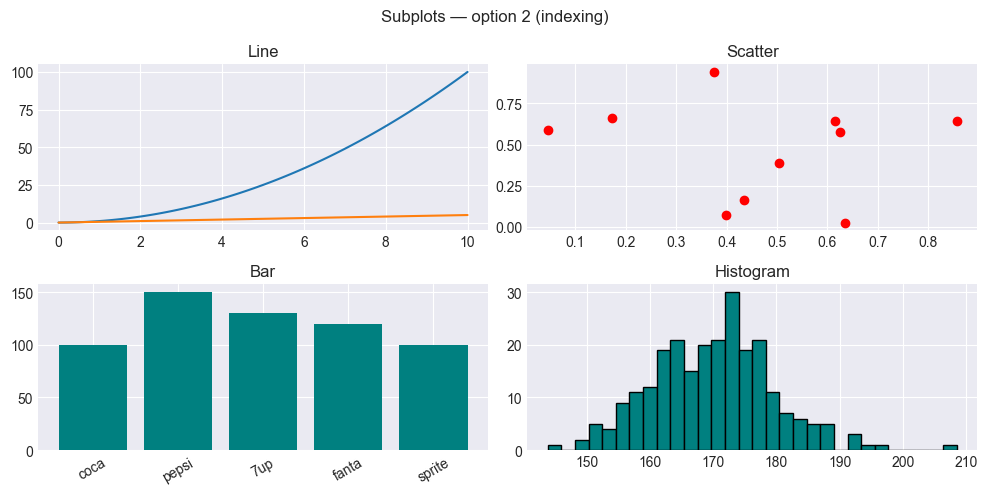

In [19]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

x = np.linspace(0, 10, 100)

ax[0, 0].plot(x, x**2)
ax[0, 0].plot(x, x / 2)
ax[0, 0].set_title("Line")

ax[0, 1].scatter(np.random.random(10), np.random.random(10), color="red")
ax[0, 1].set_title("Scatter")

ax[1, 0].bar(dic.keys(), dic.values(), color="teal")
ax[1, 0].set_title("Bar")
ax[1, 0].tick_params(axis="x", rotation=30)

ax[1, 1].hist(student_height, bins=30, edgecolor="black", color="teal")
ax[1, 1].set_title("Histogram")

fig.suptitle("Subplots — option 2 (indexing)", fontsize=12)
fig.tight_layout()
plt.show()


Hai cách **vẽ cùng một lưới**; chỉ khác cách truy cập từng ô. Cách 2 tiện khi số hàng/cột lớn hoặc thay đổi động.

Both options draw the same grid. Indexing (`ax[i, j]`) scales better when the layout is large or generated in a loop.


## 9. Tóm tắt / Summary <a id="tom-tat"></a>

| Nhu cầu / Need | Hàm / Function |
|---|---|
| Đường xu hướng, hàm số | `plot` (line) |
| Quan hệ 2 biến, phân tán | `scatter` |
| So sánh danh mục | `bar` / `barh` |
| Phân phối tần suất | `hist` |
| Nhiều hình cạnh nhau | `plt.subplots` |

**Gợi ý thực hành / Practice tips**

1. Một hình đơn → `plt.plot` / `plt.scatter` là đủ.
2. Nhiều subplot hoặc cần chỉnh từng trục → dùng `fig, ax = plt.subplots()`.
3. Luôn đặt **title, xlabel, ylabel** (và `legend` nếu có nhiều series).
4. Dấu `;` hoặc `plt.show()` để kết thúc cell vẽ trong Jupyter.

Chạy lần lượt từng cell từ trên xuống. Khi đã quen, hãy đổi dữ liệu, màu, `bins`, hoặc `figsize` để thấy biểu đồ thay đổi thế nào.

Run the cells from top to bottom. Once you are comfortable, change the data, colors, `bins`, or `figsize` to see how the plots respond.
